# Análisis de Empleo en Colombia (DANE 2002-2018)
En este proyecto realizaremos la limpieza y análisis exploratorio de la tasa de ocupación por sectores económicos en Colombia, utilizando datos oficiales del DANE.
## 1. Limpieza y Preparación de los Datos

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos usando read_excel y el nombre exacto del archivo que subiste
df = pd.read_excel('/content/Ind_empleo_1958_2018.xls', sheet_name='2002-2018', skiprows=11)

# Limpiar columnas de separación vacías y notas al pie
df = df.dropna(axis=1, how='all')
df = df.dropna(subset=['Año'])

# Formatear la columna 'Año'
df['Año'] = pd.to_numeric(df['Año'], errors='coerce').astype('Int64')

# Limpiar nombres de columnas
df.columns = df.columns.str.replace('*', '', regex=False).str.strip()

# Mostrar el resultado
print("Dimensiones de la base limpia:", df.shape)
df.head()

Dimensiones de la base limpia: (22, 12)


,Año,Agricultura,Industria,Comercio,Servicios,Agricultura.1,Industria.1,Comercio.1,Servicios.1,Tasa de subempleo subjetivo,Tasa global de participación,Tasa de ocupación
0,2002,20.673629,13.328855,25.328765,34.180897,NaN,NaN,NaN,NaN,34.750388,62.249443,52.564347
1,2003,21.237858,13.383767,25.286252,34.138250,NaN,NaN,NaN,NaN,32.228675,62.806488,53.959668
2,2004,20.350320,13.844031,25.338507,34.170492,NaN,NaN,NaN,NaN,31.766282,61.462790,53.074923
3,2005,20.705563,13.694341,25.058614,34.188413,NaN,NaN,NaN,NaN,31.869632,60.522963,53.383705
4,2006,19.095104,13.127494,24.661313,34.357401,NaN,NaN,NaN,NaN,33.914268,59.124075,52.009604


## 2. Análisis Descriptivo de los Sectores Económicos
Antes de visualizar las tendencias, es fundamental comprender la distribución estadística de la ocupación en los principales sectores económicos de Colombia durante el periodo 2002-2018.

En la siguiente celda generamos un resumen estadístico para las variables de **Agricultura, Industria, Comercio y Servicios**. Esto nos permitirá identificar el promedio de participación de cada sector, así como sus valores máximos y mínimos históricos en este marco de tiempo.

In [19]:
# Seleccionamos las principales categorías de ocupados para el análisis
sectores = ['Agricultura', 'Industria', 'Comercio', 'Servicios']

# resumen estadístico
resumen = df[sectores].describe()

print("Resumen Estadístico de Ocupación por Sector (%):")
display(resumen)

Resumen Estadístico de Ocupación por Sector (%):


,Agricultura,Industria,Comercio,Servicios
count,17.000000,17.000000,17.000000,17.000000
mean,18.249841,12.767618,26.222186,35.575655
std,1.708081,0.743029,1.002192,1.090932
min,16.094700,11.509053,24.661313,34.138250
25%,16.743346,12.025467,25.328765,34.357401
50%,18.210270,13.006936,26.219250,35.579842
75%,19.095104,13.328855,27.156999,36.667745
max,21.237858,13.844031,27.875391,36.920297


## 3. Visualización de Tendencias (2002 - 2018)
Para comprender la dinámica del mercado laboral colombiano, proyectaremos la evolución temporal de los cuatro sectores principales.

**Hipótesis inicial:** Se espera observar una transición de un modelo tradicional (mayor peso en agricultura) hacia una economía enfocada en el sector terciario (servicios y comercio). El siguiente gráfico de líneas nos permitirá confirmar o refutar esta tendencia estructural.

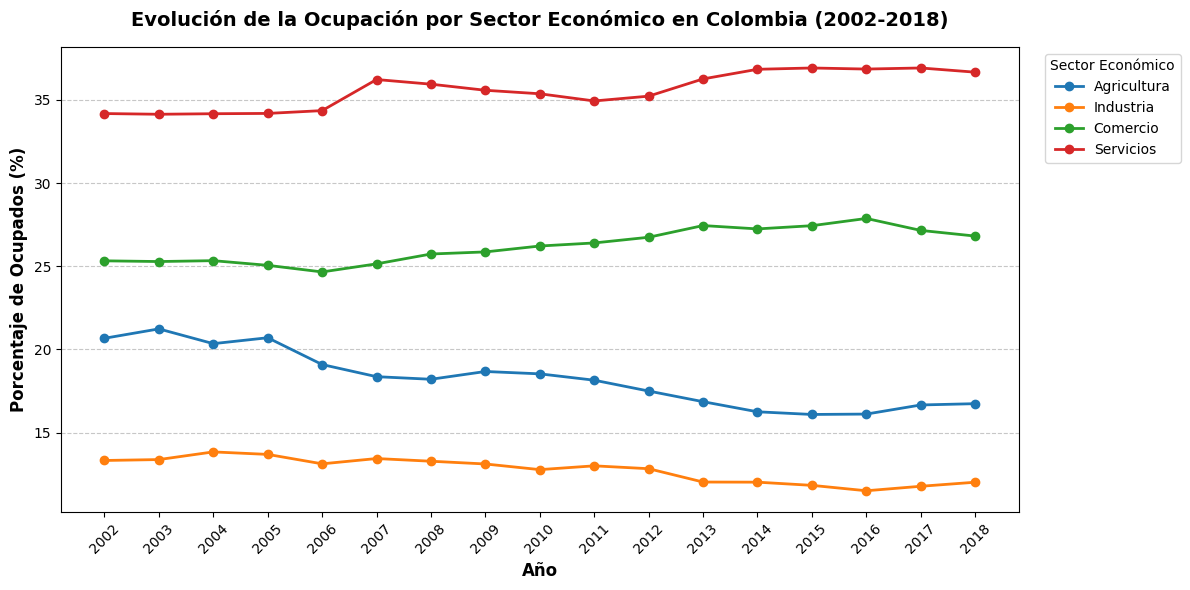

In [20]:
import matplotlib.pyplot as plt

# Configuración del estilo del gráfico
plt.figure(figsize=(12, 6))

# Trazar las líneas para cada sector principal
for sector in sectores:
    plt.plot(df['Año'], df[sector], marker='o', linewidth=2, label=sector)

# Personalización
plt.title('Evolución de la Ocupación por Sector Económico en Colombia (2002-2018)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Año', fontsize=12, fontweight='bold')
plt.ylabel('Porcentaje de Ocupados (%)', fontsize=12, fontweight='bold')

plt.xticks(df['Año'].dropna().unique(), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Sector Económico', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

# Mostrar el gráfico
plt.show()

### 📌 Conclusiones Preliminares
A partir de la visualización anterior, podemos extraer los siguientes *insights* sobre el mercado laboral en Colombia (2002-2018):
1. **Dominancia del Sector Terciario:** Los *Servicios* se consolidan como la principal fuente de empleo, manteniéndose por encima del 34% de participación durante todo el periodo analizado.
2. **Declive Agrícola:** Se evidencia una clara tendencia a la baja en la *Agricultura*, que pierde cerca de 4 puntos porcentuales de participación, reflejando una migración laboral hacia zonas urbanas o sectores de mayor valor agregado.
3. **Estabilidad Industrial:** El sector *Industria* se mantiene como el de menor participación relativa, oscilando de forma plana alrededor del 12-13%, lo que sugiere un estancamiento en la industrialización de la fuerza laboral.

# Análisis Histórico de Largo Plazo (1958 - 2011)
Para entender el contexto completo de la transición laboral en Colombia, incorporamos la serie histórica desde 1958. Este segundo conjunto de datos nos permite ver el panorama macro, aunque utiliza una metodología anterior a la del periodo 2002-2018.

A continuación, realizaremos el mismo proceso de limpieza ETL sobre este archivo para prepararlo y visualizar el gran cambio estructural del país en las últimas décadas.

In [21]:
# 1. Cargar la serie histórica directamente desde el Excel maestro, usando la hoja correspondiente
df_historico = pd.read_excel('/content/Ind_empleo_1958_2018.xls', sheet_name='1958-2011', skiprows=11)

# 2. Limpieza estructural
df_historico = df_historico.dropna(axis=1, how='all')
df_historico = df_historico.dropna(subset=['Año'])
df_historico['Año'] = pd.to_numeric(df_historico['Año'], errors='coerce').astype('Int64')
df_historico.columns = df_historico.columns.str.replace('*', '', regex=False).str.strip()

# 3. Verificamos que esté limpio
print("Dimensiones de la base histórica:", df_historico.shape)
display(df_historico.head())

Dimensiones de la base histórica: (67, 12)


,Año,Agricultura,Industria,Comercio,Servicios,Agricultura.1,Industria.1,Comercio.1,Servicios.1,Tasa de subempleo subjetivo,Tasa global de participación,Tasa de ocupación
0,1958,54.833597,5.342993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1959,54.333851,5.497672,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1960,53.714533,5.501408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1961,53.121693,5.544974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1962,52.523790,5.730244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Comparativa y Empalme de Series: El Solapamiento (2002-2011)
Al unir bases de datos históricas, es común enfrentarse a cambios en la forma en que se recolecta la información. En nuestro caso, el DANE actualizó su metodología de encuestas de hogares, lo que generó un periodo de solapamiento donde tenemos datos de ambas series para los mismos años (2002 a 2011).

En lugar de unir las tablas a ciegas, en el siguiente panel de gráficos compararemos el comportamiento de los cuatro sectores económicos durante ese cruce metodológico. Esto nos permitirá identificar visualmente cómo el cambio en la recolección de datos (de la serie histórica a la serie reciente) ajustó los porcentajes de ocupación reportados en la realidad.

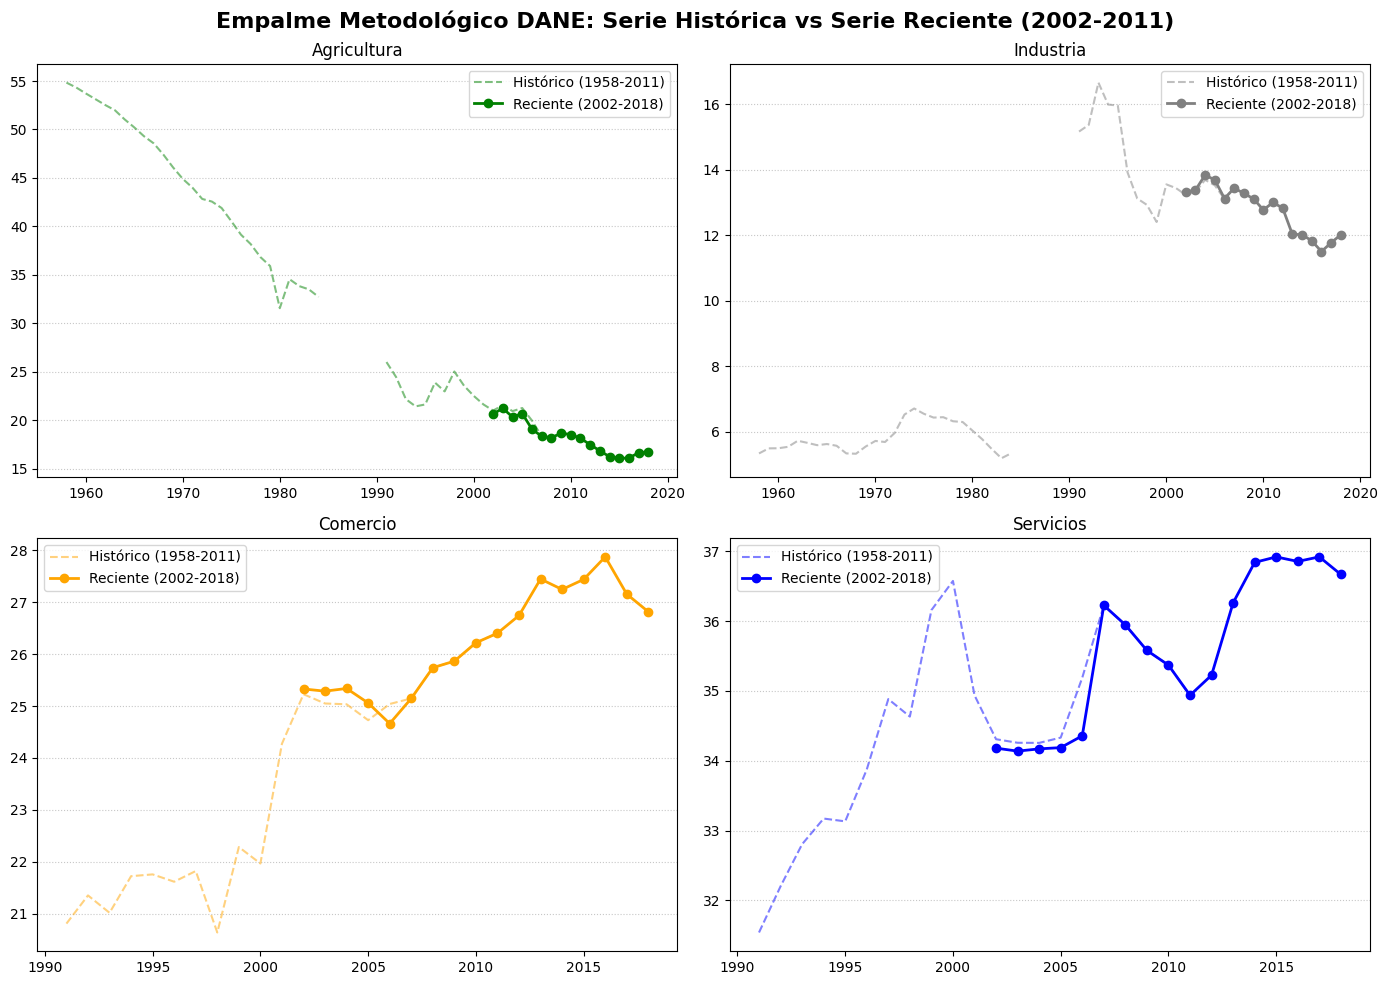

In [22]:
# Crear una figura con 4 sub-gráficos (2 filas, 2 columnas)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Empalme Metodológico DANE: Serie Histórica vs Serie Reciente (2002-2011)', fontsize=16, fontweight='bold')

sectores_plot = ['Agricultura', 'Industria', 'Comercio', 'Servicios']
colores = ['green', 'gray', 'orange', 'blue']

# Graficar cada sector en su propio panel
for i, ax in enumerate(axs.flat):
    sector = sectores_plot[i]
    color = colores[i]

    # Línea histórica (punteada)
    ax.plot(df_historico['Año'], df_historico[sector], linestyle='--', color=color, alpha=0.5, label='Histórico (1958-2011)')
    # Línea reciente (sólida)
    ax.plot(df['Año'], df[sector], marker='o', color=color, linewidth=2, label='Reciente (2002-2018)')

    ax.set_title(sector, fontsize=12)
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()

### 📌 Conclusiones Finales y Reflexión Metodológica
1. **Transformación Estructural Profunda:** Al observar la serie desde 1958, el cambio es drástico. Colombia pasó de tener más del 50% de su población ocupada en el campo a mediados del siglo XX, a consolidarse como una economía de servicios (terciarizada) en la segunda década del siglo XXI.
2. **El Reto de las Series Temporales Empalmadas:** Al graficar el periodo de solapamiento (2002-2011), se hace evidente un salto estadístico provocado por el cambio metodológico del DANE. La serie nueva reporta un porcentaje de ocupación agrícola ligeramente mayor que la serie antigua para los mismos años.
3. **Decisión Analítica:** Para un análisis continuo ininterrumpido (1958-2018), sería necesario aplicar técnicas de empalme estadístico (retropolación) usando la nueva metodología como base. Por ahora, mantenerlas separadas nos permite ser transparentes con la procedencia y exactitud de los datos originales.